# OCT - EfficientNet-B0 Accuracy-Balanced | 3 Sinif | VS Code Local

Bu notebook EfficientNet-B0 accuracy-balanced deneyinin local/VS Code surumudur.

Kisitlar:

- TTA yok.
- Top-k hasta secimi yok.
- Ensemble yok.
- K-fold yok.
- Veri Google Drive'dan degil, lokal proje klasorunden okunur.

Beklenen lokal proje yapisi:

```text
C:/Users/yunus/Desktop/bitirmep/data/OCT
C:/Users/yunus/Desktop/bitirmep/data/Textlabels.xlsx
C:/Users/yunus/Desktop/bitirmep/data/split_3sinif.json
```

Sonuclar `C:/Users/yunus/Desktop/bitirmep/outputs/efficientnet_b0_accuracy_balanced_oct_3sinif_vscode` altina yazilir.


In [1]:
# -- HUCRE 1: Kutuphaneler -----------------------------------------
import csv
import json
import random
import re
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

warnings.filterwarnings('ignore')
ImageFile.LOAD_TRUNCATED_IMAGES = True

print('Kutuphaneler hazir.')


c:\Users\yunus\anaconda3\envs\odir_cnn_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Kutuphaneler hazir.


In [2]:
# -- HUCRE 2: Lokal yollar ve sabitler ------------------------------
PROJECT_ROOT = Path(r'C:/Users/yunus/Desktop/bitirmep')
DATA_DIR = PROJECT_ROOT / 'data'
DATA_OCT = DATA_DIR / 'OCT'
EXCEL_PATH = DATA_DIR / 'Textlabels.xlsx'
SPLIT_PATH = DATA_DIR / 'split_3sinif.json'

SAVE_DIR = PROJECT_ROOT / 'outputs' / 'efficientnet_b0_accuracy_balanced_oct_3sinif_vscode'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

required_paths = [DATA_OCT, EXCEL_PATH, SPLIT_PATH]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(f'Lokal veri yolu eksik: {missing_paths}')

CLASS_NAMES = ['NORMAL', 'DR', 'AMD']
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}

NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 40
MAX_LR = 5e-4
PATIENCE = 10
FREEZE_EPOCHS = 2
MIXUP_ALPHA = 0.15
MIXUP_PROB = 0.25
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP = device.type == 'cuda'
if device.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('CUDA bulunamadi; CPU ile calisilacak. Egitim cok yavas olabilir.')

print(f'Proje klasoru : {PROJECT_ROOT}')
print(f'Veri klasoru  : {DATA_DIR}')
print(f'OCT klasoru  : {DATA_OCT}')
print(f'Ortak split   : {SPLIT_PATH}')
print(f'Cikti klasoru : {SAVE_DIR}')


GPU: NVIDIA GeForce GTX 1650
Proje klasoru : C:\Users\yunus\Desktop\bitirmep
Veri klasoru  : C:\Users\yunus\Desktop\bitirmep\data
OCT klasoru  : C:\Users\yunus\Desktop\bitirmep\data\OCT
Ortak split   : C:\Users\yunus\Desktop\bitirmep\data\split_3sinif.json
Cikti klasoru : C:\Users\yunus\Desktop\bitirmep\outputs\efficientnet_b0_accuracy_balanced_oct_3sinif_vscode


In [3]:
# -- HUCRE 3: Yardimci siniflar ve fonksiyonlar ---------------------
def clean_patient_id(x):
    if pd.isna(x):
        return None
    if isinstance(x, float) and x.is_integer():
        return str(int(x))
    s = str(x).strip()
    if s.endswith('.0') and s[:-2].isdigit():
        s = s[:-2]
    return s


def norm_label(x):
    return str(x).strip().upper()


def natural_key(path):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', str(path))]


def find_col(columns, candidates):
    lower_map = {str(c).strip().lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    raise ValueError(f'Beklenen kolon bulunamadi. Adaylar={candidates}, mevcut={list(columns)}')


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.register_buffer(
            'alpha',
            torch.tensor(alpha, dtype=torch.float32) if alpha is not None else None,
        )

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        loss = ((1.0 - pt) ** self.gamma) * ce_loss
        if self.alpha is not None:
            alpha = self.alpha.to(inputs.device)
            loss = alpha.gather(0, targets.view(-1)) * loss
        if self.reduction == 'sum':
            return loss.sum()
        return loss.mean()


class EyeDataset(Dataset):
    def __init__(self, dataframe, transform=None, return_patient=False):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.return_patient = return_patient

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['img_path']).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        label = int(row['label'])
        if self.return_patient:
            return image, label, str(row['patient_id'])
        return image, label


def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1.0 - lam) * x[index]
    return mixed_x, y, y[index], lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1.0 - lam) * criterion(pred, y_b)


def freeze_backbone(m):
    for name, param in m.named_parameters():
        if 'classifier' not in name:
            param.requires_grad = False


def unfreeze_backbone(m):
    for param in m.parameters():
        param.requires_grad = True


def safe_macro_auc(labels, probs):
    try:
        labels_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))
        return roc_auc_score(labels_bin, probs, multi_class='ovr', average='macro')
    except Exception:
        return float('nan')


def summarize_metrics(labels, preds, probs, level, decision):
    row = {
        'level': level,
        'decision': decision,
        'accuracy': accuracy_score(labels, preds),
        'balanced_accuracy': balanced_accuracy_score(labels, preds),
        'macro_precision': precision_score(labels, preds, average='macro', zero_division=0),
        'macro_recall': recall_score(labels, preds, average='macro', zero_division=0),
        'macro_f1': f1_score(labels, preds, average='macro', zero_division=0),
    }
    if probs is not None:
        row['macro_auc_ovr'] = safe_macro_auc(labels, probs)
    for idx, class_name in enumerate(CLASS_NAMES):
        key = class_name.lower()
        row[f'{key}_recall'] = recall_score(labels, preds, labels=[idx], average=None, zero_division=0)[0]
        row[f'{key}_f1'] = f1_score(labels, preds, labels=[idx], average=None, zero_division=0)[0]
    return row


print('Yardimci fonksiyonlar hazir.')


Yardimci fonksiyonlar hazir.


In [4]:
# -- HUCRE 4: Veri yukleme - CNV filtreleme - split okuma -----------
df_raw = pd.read_excel(EXCEL_PATH)
df_raw.columns = df_raw.columns.str.strip()
id_col = find_col(df_raw.columns, ['ID', 'Id', 'Patient ID', 'PatientID', 'Hasta ID', 'Hasta No'])
disease_col = find_col(df_raw.columns, ['Disease', 'Diagnosis', 'Class', 'Label', 'Hastalik'])

df = df_raw[[id_col, disease_col]].copy()
df.columns = ['patient_id', 'disease']
df['patient_id'] = df['patient_id'].map(clean_patient_id)
df['disease'] = df['disease'].map(norm_label)
df = (
    df[df['disease'].isin(CLASS_NAMES)]
    .dropna(subset=['patient_id', 'disease'])
    .drop_duplicates('patient_id')
    .reset_index(drop=True)
)
df['label'] = df['disease'].map(CLASS_TO_IDX).astype(int)

print(f'CNV cikarildi -> kalan hasta: {len(df)}')
print(df['disease'].value_counts().reindex(CLASS_NAMES, fill_value=0))

missing = []
records = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Goruntu listesi'):
    pid = row['patient_id']
    patient_dir = DATA_OCT / pid
    if not patient_dir.exists():
        missing.append(pid)
        continue
    files = sorted(patient_dir.glob('*.bmp'), key=natural_key)
    for img_file in files:
        records.append(
            {
                'img_path': str(img_file),
                'path': str(img_file),
                'label': int(row['label']),
                'disease': row['disease'],
                'patient_id': pid,
            }
        )

if missing:
    print(f'Uyari: Lokal OCT icinde eksik hasta klasoru sayisi: {len(missing)} | Ornek: {missing[:10]}')

img_df = pd.DataFrame(records)
if img_df.empty:
    raise RuntimeError(f'Goruntu bulunamadi: {DATA_OCT}')

expected_patients = df['patient_id'].nunique() - len(missing)
assert img_df['patient_id'].nunique() == expected_patients, f'Goruntulu hasta sayisi hatali: {img_df["patient_id"].nunique()} / {expected_patients}'
assert len(img_df) > 0, 'Goruntu bulunamadi.'
patient_image_counts = img_df.groupby('patient_id').size()
assert patient_image_counts.min() > 0, patient_image_counts.describe()

with open(SPLIT_PATH, 'r', encoding='utf-8') as f:
    split = json.load(f)

train_ids = set(clean_patient_id(pid) for pid in split['train'])
val_ids = set(clean_patient_id(pid) for pid in split['val'])
test_ids = set(clean_patient_id(pid) for pid in split['test'])

if train_ids & val_ids or train_ids & test_ids or val_ids & test_ids:
    raise RuntimeError('Split dosyasinda hasta sizintisi var.')

all_split_ids = train_ids | val_ids | test_ids
all_patient_ids = set(df['patient_id'])
if all_split_ids != all_patient_ids:
    raise RuntimeError(
        f'Split hasta listesi ile Excel uyusmuyor. '
        f'Splitte olup Excelde olmayan: {sorted(all_split_ids - all_patient_ids)[:10]}, '
        f'Excelde olup splitte olmayan: {sorted(all_patient_ids - all_split_ids)[:10]}'
    )

train_df = img_df[img_df['patient_id'].isin(train_ids)].reset_index(drop=True)
val_df = img_df[img_df['patient_id'].isin(val_ids)].reset_index(drop=True)
test_df = img_df[img_df['patient_id'].isin(test_ids)].reset_index(drop=True)

print(f'Toplam goruntu: {len(img_df)}')
print(f'Toplam hasta  : {img_df["patient_id"].nunique()} / {df["patient_id"].nunique()}')
print(f'Train: {len(train_df):>6} goruntu | {train_df["patient_id"].nunique()} hasta')
print(f'Val  : {len(val_df):>6} goruntu | {val_df["patient_id"].nunique()} hasta')
print(f'Test : {len(test_df):>6} goruntu | {test_df["patient_id"].nunique()} hasta')

for name, part in [('TRAIN', train_df), ('VAL', val_df), ('TEST', test_df)]:
    patient_counts = part.drop_duplicates('patient_id')['disease'].value_counts().reindex(CLASS_NAMES, fill_value=0)
    image_counts = part['disease'].value_counts().reindex(CLASS_NAMES, fill_value=0)
    print(f'\n{name} hasta dagilimi:')
    print(patient_counts)
    print(f'{name} goruntu dagilimi:')
    print(image_counts)


CNV cikarildi -> kalan hasta: 195
disease
NORMAL    160
DR         29
AMD         6
Name: count, dtype: int64


Goruntu listesi: 100%|██████████| 195/195 [00:00<00:00, 198.37it/s]

Uyari: Lokal OCT icinde eksik hasta klasoru sayisi: 2 | Ornek: ['10400', '10500']
Toplam goruntu: 58551
Toplam hasta  : 193 / 195
Train:  39703 goruntu | 131 hasta
Val  :   7296 goruntu | 24 hasta
Test :  11552 goruntu | 38 hasta

TRAIN hasta dagilimi:
disease
NORMAL    107
DR         20
AMD         4
Name: count, dtype: int64
TRAIN goruntu dagilimi:
disease
NORMAL    32435
DR         6052
AMD        1216
Name: count, dtype: int64

VAL hasta dagilimi:
disease
NORMAL    20
DR         3
AMD        1
Name: count, dtype: int64
VAL goruntu dagilimi:
disease
NORMAL    6080
DR         912
AMD        304
Name: count, dtype: int64

TEST hasta dagilimi:
disease
NORMAL    31
DR         6
AMD        1
Name: count, dtype: int64
TEST goruntu dagilimi:
disease
NORMAL    9424
DR        1824
AMD        304
Name: count, dtype: int64


In [5]:
# -- HUCRE 5: Augmentation, dataset ve sampler ----------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 24, IMG_SIZE + 24)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.82, 1.0), ratio=(0.95, 1.05)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.15),
    transforms.RandomRotation(degrees=10),
    transforms.RandAugment(num_ops=2, magnitude=7),
    transforms.ColorJitter(brightness=0.12, contrast=0.14, saturation=0.05, hue=0.01),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.10, scale=(0.02, 0.08), ratio=(0.3, 3.3)),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

label_counts = train_df['label'].value_counts().sort_index().reindex(range(NUM_CLASSES), fill_value=0).values.astype(np.float32)
class_weights = len(train_df) / (NUM_CLASSES * np.maximum(label_counts, 1))
class_weights[1] *= 1.25
class_weights[2] *= 1.10

print('Sinif agirliklari:')
for name, weight in zip(CLASS_NAMES, class_weights):
    print(f'  {name}: {weight:.4f}')

train_dataset = EyeDataset(train_df, transform=train_transform)
val_dataset = EyeDataset(val_df, transform=eval_transform)
test_dataset = EyeDataset(test_df, transform=eval_transform, return_patient=True)

sample_weights = train_df['label'].map({i: class_weights[i] for i in range(NUM_CLASSES)}).values.astype(np.float32)
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

NUM_WORKERS = 0  # VS Code multiprocessing uyarilarini engellemek icin 0
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'))

val_patient_dataset = EyeDataset(val_df, transform=eval_transform, return_patient=True)
val_patient_loader = DataLoader(val_patient_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'))

print('DataLoader, WeightedRandomSampler, RandAugment ve MixUp hazir.')


Sinif agirliklari:
  NORMAL: 0.4080
  DR: 2.7335
  AMD: 11.9718
DataLoader, WeightedRandomSampler, RandAugment ve MixUp hazir.


In [6]:
# -- HUCRE 6: EfficientNet-B0 model, loss, optimizer --------------------
weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.40),
    nn.Linear(num_features, 384),
    nn.SiLU(inplace=True),
    nn.BatchNorm1d(384),
    nn.Dropout(p=0.25),
    nn.Linear(384, 128),
    nn.SiLU(inplace=True),
    nn.BatchNorm1d(128),
    nn.Dropout(p=0.15),
    nn.Linear(128, NUM_CLASSES),
)
model = model.to(device)

focal_criterion = FocalLoss(alpha=class_weights, gamma=2.0).to(device)

def combined_loss(outputs, labels):
    return focal_criterion(outputs, labels)

freeze_backbone(model)

backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]
head_params = list(model.classifier.parameters())

optimizer = optim.AdamW(
    [
        {'params': backbone_params, 'lr': MAX_LR / 15},
        {'params': head_params, 'lr': MAX_LR},
    ],
    weight_decay=1e-4,
)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[MAX_LR / 15, MAX_LR],
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.15,
    anneal_strategy='cos',
)

scaler = torch.cuda.amp.GradScaler(enabled=AMP)
CHECKPOINT = SAVE_DIR / 'efficientnet_b0_accuracy_balanced_best.pth'

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Toplam parametre  : {total_params:,}')
print(f'Egitilebilir param: {trainable_params:,} (ilk {FREEZE_EPOCHS} epoch backbone donuk)')
print(f'Checkpoint        : {CHECKPOINT}')


Toplam parametre  : 4,550,143
Egitilebilir param: 542,595 (ilk 2 epoch backbone donuk)
Checkpoint        : C:\Users\yunus\Desktop\bitirmep\outputs\efficientnet_b0_accuracy_balanced_oct_3sinif_vscode\efficientnet_b0_accuracy_balanced_best.pth


In [7]:
# -- HUCRE 7: Egitim dongusu - image + patient dengeli ---------------
history = []
best_score = -1.0
best_val_loss = float('inf')
patience_counter = 0

def evaluate_loader(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    preds_all, labels_all, probs_all, patients_all = [], [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='val', leave=False):
            if len(batch) == 3:
                images, labels, patient_ids = batch
            else:
                images, labels = batch
                patient_ids = [None] * len(labels)
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=AMP):
                outputs = model(images)
                loss = combined_loss(outputs, labels)
            probs = F.softmax(outputs, dim=1)
            preds = outputs.argmax(1)
            total_loss += loss.item() * images.size(0)
            correct += (preds == labels).sum().item()
            total += images.size(0)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
            probs_all.extend(probs.cpu().numpy())
            patients_all.extend(list(patient_ids))

    labels_all = np.array(labels_all)
    preds_all = np.array(preds_all)
    probs_all = np.array(probs_all)
    result = {
        'loss': total_loss / total,
        'acc': correct / total,
        'macro_f1': f1_score(labels_all, preds_all, average='macro', zero_division=0),
        'bal_acc': balanced_accuracy_score(labels_all, preds_all),
        'dr_recall': recall_score(labels_all, preds_all, labels=[1], average=None, zero_division=0)[0],
        'amd_recall': recall_score(labels_all, preds_all, labels=[2], average=None, zero_division=0)[0],
        'auc': safe_macro_auc(labels_all, probs_all),
    }
    if patients_all and patients_all[0] is not None:
        tmp = pd.DataFrame({
            'patient_id': patients_all,
            'true': labels_all,
            'p_normal': probs_all[:, 0],
            'p_dr': probs_all[:, 1],
            'p_amd': probs_all[:, 2],
        })
        patient_df_eval = tmp.groupby('patient_id').agg({
            'true': 'first',
            'p_normal': 'mean',
            'p_dr': 'mean',
            'p_amd': 'mean',
        }).reset_index()
        patient_true_eval = patient_df_eval['true'].values
        patient_probs_eval = patient_df_eval[['p_normal', 'p_dr', 'p_amd']].values
        patient_preds_eval = patient_probs_eval.argmax(axis=1)
        result.update({
            'patient_acc': accuracy_score(patient_true_eval, patient_preds_eval),
            'patient_bal_acc': balanced_accuracy_score(patient_true_eval, patient_preds_eval),
            'patient_macro_f1': f1_score(patient_true_eval, patient_preds_eval, average='macro', zero_division=0),
        })
    else:
        result.update({'patient_acc': np.nan, 'patient_bal_acc': np.nan, 'patient_macro_f1': np.nan})
    return result

print('EGITIM BASLIYOR...')
print(f'{"Epoch":>5} | {"TrLoss":>8} | {"TrAcc":>7} | {"ImgAcc":>7} | {"ImgBal":>7} | {"PatAcc":>7} | {"PatBal":>7} | Durum')
print('-' * 108)

for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == FREEZE_EPOCHS + 1:
        unfreeze_backbone(model)
        print(f'  Epoch {epoch}: backbone acildi, fine-tuning basliyor.')

    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    counted_total = 0

    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch} train', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        use_mixup = np.random.rand() < MIXUP_PROB
        with torch.cuda.amp.autocast(enabled=AMP):
            if use_mixup:
                mixed_images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=MIXUP_ALPHA)
                outputs = model(mixed_images)
                loss = mixup_criterion(combined_loss, outputs, labels_a, labels_b, lam)
            else:
                outputs = model(images)
                loss = combined_loss(outputs, labels)
                tr_correct += (outputs.argmax(1) == labels).sum().item()
                counted_total += images.size(0)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        tr_loss += loss.item() * images.size(0)
        tr_total += images.size(0)

    train_loss = tr_loss / tr_total
    train_acc = (tr_correct / counted_total) if counted_total > 0 else 0.0
    val_metrics = evaluate_loader(val_patient_loader)

    score = (0.25 * val_metrics['acc'] + 0.20 * val_metrics['bal_acc'] + 0.15 * val_metrics['macro_f1'] + 0.25 * val_metrics['patient_acc'] + 0.15 * val_metrics['patient_bal_acc'])
    improved = score > best_score or (np.isclose(score, best_score) and val_metrics['loss'] < best_val_loss)

    if improved:
        best_score = score
        best_val_loss = val_metrics['loss']
        patience_counter = 0
        torch.save(
            {
                'model_state_dict': model.state_dict(),
                'classes': CLASS_NAMES,
                'epoch': epoch,
                'best_score': best_score,
                'val_metrics': val_metrics,
            },
            CHECKPOINT,
        )
        status = 'BEST'
    else:
        patience_counter += 1
        status = f'wait {patience_counter}/{PATIENCE}'

    history.append(
        {
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_metrics['loss'],
            'val_acc': val_metrics['acc'],
            'val_macro_f1': val_metrics['macro_f1'],
            'val_bal_acc': val_metrics['bal_acc'],
            'val_dr_recall': val_metrics['dr_recall'],
            'val_amd_recall': val_metrics['amd_recall'],
            'val_auc': val_metrics['auc'],
            'val_patient_acc': val_metrics['patient_acc'],
            'val_patient_bal_acc': val_metrics['patient_bal_acc'],
            'val_patient_macro_f1': val_metrics['patient_macro_f1'],
            'score': score,
        }
    )

    print(
        f'{epoch:5d} | {train_loss:8.4f} | {train_acc*100:6.2f}% | '
        f'{val_metrics["acc"]:7.4f} | {val_metrics["bal_acc"]:7.4f} | '
        f'{val_metrics["patient_acc"]:7.4f} | {val_metrics["patient_bal_acc"]:7.4f} | {status}'
    )

    if patience_counter >= PATIENCE:
        print(f'Erken durdurma: {PATIENCE} epoch iyilesme yok.')
        break

history_df = pd.DataFrame(history)
history_df.to_csv(SAVE_DIR / 'history.csv', index=False)
print('Egitim tamamlandi. En iyi skor:', best_score)


EGITIM BASLIYOR...
Epoch |   TrLoss |   TrAcc |  ImgAcc |  ImgBal |  PatAcc |  PatBal | Durum
------------------------------------------------------------------------------------------------------------


    1 |   1.8594 |  52.23% |  0.5424 |  0.6782 |  0.6667 |  0.8667 | BEST


    2 |   1.0396 |  56.49% |  0.4964 |  0.6342 |  0.6667 |  0.8667 | wait 1/10
  Epoch 3: backbone acildi, fine-tuning basliyor.


    3 |   0.5854 |  69.98% |  0.7734 |  0.6726 |  0.8333 |  0.6167 | BEST


    4 |   0.4111 |  82.79% |  0.7421 |  0.6725 |  0.8333 |  0.9333 | BEST


...

   28 |   0.0716 |  99.54% |  0.8983 |  0.6496 |  0.9167 |  0.5556 | wait 1/10


   29 |   0.0687 |  99.54% |  0.9017 |  0.6185 |  0.9167 |  0.5556 | wait 2/10


   30 |   0.0711 |  99.59% |  0.9049 |  0.6761 |  0.9583 |  0.8889 | BEST


   31 |   0.0693 |  99.57% |  0.9095 |  0.6447 |  0.9167 |  0.5556 | wait 1/10


KeyboardInterrupt: 

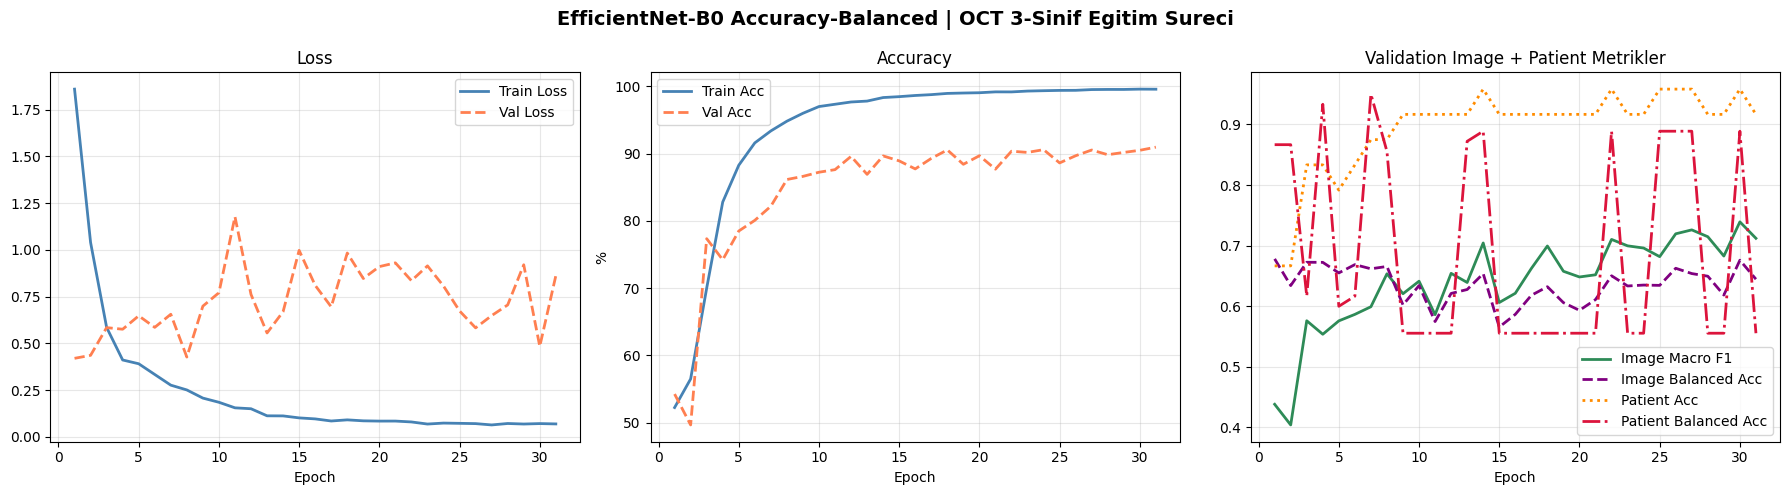

Egitim grafikleri kaydedildi: C:\Users\yunus\Desktop\bitirmep\outputs\efficientnet_b0_accuracy_balanced_oct_3sinif_vscode\efficientnet_b0_accuracy_balanced_training_curves.png


In [8]:
# -- HUCRE 8: Egitim grafikleri ------------------------------------
hist = pd.DataFrame(history)
epochs_x = hist['epoch']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EfficientNet-B0 Accuracy-Balanced | OCT 3-Sinif Egitim Sureci', fontsize=14, fontweight='bold')

axes[0].plot(epochs_x, hist['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(epochs_x, hist['val_loss'], label='Val Loss', color='coral', linestyle='--', linewidth=2)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_x, hist['train_acc'] * 100, label='Train Acc', color='steelblue', linewidth=2)
axes[1].plot(epochs_x, hist['val_acc'] * 100, label='Val Acc', color='coral', linestyle='--', linewidth=2)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('%')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(epochs_x, hist['val_macro_f1'], label='Image Macro F1', color='seagreen', linewidth=2)
axes[2].plot(epochs_x, hist['val_bal_acc'], label='Image Balanced Acc', color='purple', linestyle='--', linewidth=2)
axes[2].plot(epochs_x, hist['val_patient_acc'], label='Patient Acc', color='darkorange', linestyle=':', linewidth=2)
axes[2].plot(epochs_x, hist['val_patient_bal_acc'], label='Patient Balanced Acc', color='crimson', linestyle='-.', linewidth=2)
axes[2].set_title('Validation Image + Patient Metrikler')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
training_curve_path = SAVE_DIR / 'efficientnet_b0_accuracy_balanced_training_curves.png'
plt.savefig(training_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print('Egitim grafikleri kaydedildi:', training_curve_path)


test: 100%|██████████| 722/722 [03:00<00:00,  4.01it/s]


IMAGE-LEVEL TEST RAPORU
              precision    recall  f1-score   support

      NORMAL     0.9559    0.9914    0.9733      9424
          DR     0.9466    0.7675    0.8477      1824
         AMD     0.9933    0.9770    0.9851       304

    accuracy                         0.9557     11552
   macro avg     0.9653    0.9120    0.9354     11552
weighted avg     0.9554    0.9557    0.9538     11552

Balanced Accuracy: 0.9120
Macro AUC OvR    : 0.9508


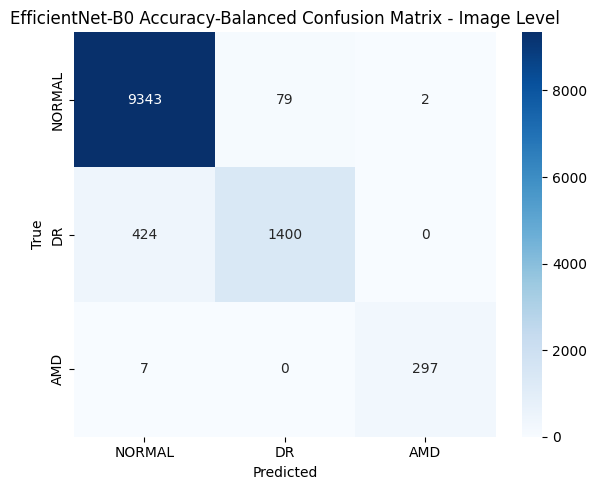

Image CM kaydedildi: C:\Users\yunus\Desktop\bitirmep\outputs\efficientnet_b0_accuracy_balanced_oct_3sinif_vscode\efficientnet_b0_accuracy_balanced_confusion_matrix_image.png


In [9]:
# -- HUCRE 9: Test tahminleri - image level -------------------------
checkpoint = torch.load(CHECKPOINT, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_probs, all_labels, all_patients = [], [], []
with torch.no_grad():
    for images, labels, patient_ids in tqdm(test_loader, desc='test'):
        images = images.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=AMP):
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.extend(labels.numpy().tolist())
        all_patients.extend(list(patient_ids))

test_probs = np.concatenate(all_probs, axis=0)
test_labels = np.array(all_labels)
test_preds = test_probs.argmax(axis=1)

print('IMAGE-LEVEL TEST RAPORU')
print('=' * 70)
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4, zero_division=0))
print(f'Balanced Accuracy: {balanced_accuracy_score(test_labels, test_preds):.4f}')
print(f'Macro AUC OvR    : {safe_macro_auc(test_labels, test_probs):.4f}')

cm_img = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_img, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('EfficientNet-B0 Accuracy-Balanced Confusion Matrix - Image Level')
plt.tight_layout()
image_cm_path = SAVE_DIR / 'efficientnet_b0_accuracy_balanced_confusion_matrix_image.png'
plt.savefig(image_cm_path, dpi=150, bbox_inches='tight')
plt.show()
print('Image CM kaydedildi:', image_cm_path)


PATIENT-LEVEL TEST RAPORU
              precision    recall  f1-score   support

      NORMAL     0.9688    1.0000    0.9841        31
          DR     1.0000    0.8333    0.9091         6
         AMD     1.0000    1.0000    1.0000         1

    accuracy                         0.9737        38
   macro avg     0.9896    0.9444    0.9644        38
weighted avg     0.9745    0.9737    0.9727        38

Patient Balanced Accuracy: 0.9444


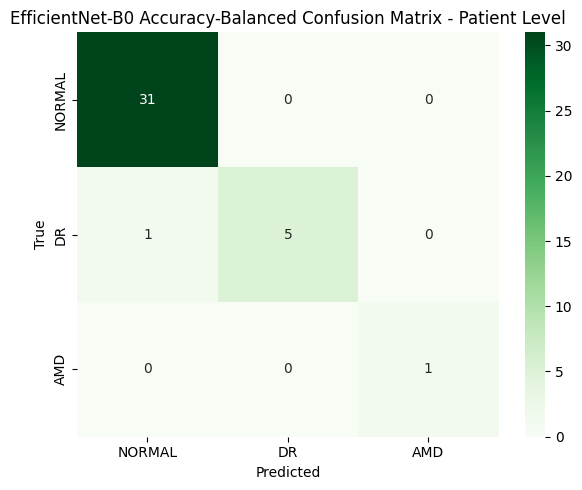

Patient CM kaydedildi: C:\Users\yunus\Desktop\bitirmep\outputs\efficientnet_b0_accuracy_balanced_oct_3sinif_vscode\efficientnet_b0_accuracy_balanced_confusion_matrix_patient.png


In [10]:
# -- HUCRE 10: Patient-level degerlendirme --------------------------
test_probs_df = test_df.copy().reset_index(drop=True)
test_probs_df['patient_id'] = list(all_patients)
test_probs_df['true'] = test_labels
test_probs_df['p_normal'] = test_probs[:, 0]
test_probs_df['p_dr'] = test_probs[:, 1]
test_probs_df['p_amd'] = test_probs[:, 2]

patient_df = (
    test_probs_df
    .groupby('patient_id')
    .agg({
        'true': 'first',
        'disease': 'first',
        'p_normal': 'mean',
        'p_dr': 'mean',
        'p_amd': 'mean',
        'img_path': 'count',
    })
    .rename(columns={'img_path': 'image_count'})
    .reset_index()
)

patient_true = patient_df['true'].values
patient_probs = patient_df[['p_normal', 'p_dr', 'p_amd']].values
patient_preds = patient_probs.argmax(axis=1)

patient_df['pred'] = [CLASS_NAMES[idx] for idx in patient_preds]
patient_df.to_csv(SAVE_DIR / 'efficientnet_b0_accuracy_balanced_patient_predictions.csv', index=False)

print('PATIENT-LEVEL TEST RAPORU')
print('=' * 70)
print(classification_report(patient_true, patient_preds, target_names=CLASS_NAMES, digits=4, zero_division=0))
print(f'Patient Balanced Accuracy: {balanced_accuracy_score(patient_true, patient_preds):.4f}')

cm_patient = confusion_matrix(patient_true, patient_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('EfficientNet-B0 Accuracy-Balanced Confusion Matrix - Patient Level')
plt.tight_layout()
patient_cm_path = SAVE_DIR / 'efficientnet_b0_accuracy_balanced_confusion_matrix_patient.png'
plt.savefig(patient_cm_path, dpi=150, bbox_inches='tight')
plt.show()
print('Patient CM kaydedildi:', patient_cm_path)


In [11]:
# -- HUCRE 11: Metrik tablosu ve rapor dosyasi -----------------------
metrics_summary = pd.DataFrame(
    [
        summarize_metrics(test_labels, test_preds, test_probs, level='image', decision='argmax'),
        summarize_metrics(patient_true, patient_preds, patient_probs, level='patient', decision='mean_argmax'),
    ]
)
preferred_cols = [
    'level',
    'decision',
    'accuracy',
    'balanced_accuracy',
    'macro_precision',
    'macro_recall',
    'macro_f1',
    'macro_auc_ovr',
    'normal_recall',
    'dr_recall',
    'amd_recall',
    'normal_f1',
    'dr_f1',
    'amd_f1',
]
metrics_summary = metrics_summary[[col for col in preferred_cols if col in metrics_summary.columns]]
metrics_path = SAVE_DIR / 'metrics_summary.csv'
metrics_summary.to_csv(metrics_path, index=False)

report_path = SAVE_DIR / 'test_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write('EfficientNet-B0 Accuracy-Balanced | OCT 3-Sinif | VS Code Local\n')
    f.write('=' * 70 + '\n\n')
    f.write('IMAGE-LEVEL REPORT\n')
    f.write(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4, zero_division=0))
    f.write(f'\nBalanced Accuracy: {balanced_accuracy_score(test_labels, test_preds):.4f}\n')
    f.write(f'Macro AUC OvR    : {safe_macro_auc(test_labels, test_probs):.4f}\n\n')
    f.write('PATIENT-LEVEL REPORT\n')
    f.write(classification_report(patient_true, patient_preds, target_names=CLASS_NAMES, digits=4, zero_division=0))
    f.write(f'\nPatient Balanced Accuracy: {balanced_accuracy_score(patient_true, patient_preds):.4f}\n\n')
    f.write('IMAGE CM\n')
    f.write(np.array2string(cm_img) + '\n\n')
    f.write('PATIENT CM\n')
    f.write(np.array2string(cm_patient) + '\n')

print('Metrik tablosu kaydedildi:', metrics_path)
print('Rapor kaydedildi:', report_path)
display(metrics_summary.round(4))


Metrik tablosu kaydedildi: C:\Users\yunus\Desktop\bitirmep\outputs\efficientnet_b0_accuracy_balanced_oct_3sinif_vscode\metrics_summary.csv
Rapor kaydedildi: C:\Users\yunus\Desktop\bitirmep\outputs\efficientnet_b0_accuracy_balanced_oct_3sinif_vscode\test_report.txt


,level,decision,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,macro_auc_ovr,normal_recall,dr_recall,amd_recall,normal_f1,dr_f1,amd_f1
0,image,argmax,0.9557,0.9120,0.9653,0.9120,0.9354,0.9508,0.9914,0.7675,0.977,0.9733,0.8477,0.9851
1,patient,mean_argmax,0.9737,0.9444,0.9896,0.9444,0.9644,1.0000,1.0000,0.8333,1.000,0.9841,0.9091,1.0000


## Not

Bu surum EfficientNet-B0 icin accuracy-balanced final deneyidir. TTA, top-k, ensemble ve k-fold kullanmaz. Model secimi image-level ve patient-level metrikleri birlikte dikkate alir; patient-level karar tum hasta goruntulerinin ortalama olasiligiyle verilir.
